In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

dataset_path = "/content/drive/MyDrive/Hoda 0-9"


print("آیا پوشه وجود دارد؟", os.path.exists(dataset_path))
print("مسیر دیتاست:", dataset_path)


image_paths = glob.glob(
    os.path.join(dataset_path, "**", "*.bmp"),
    recursive=True
)

print("تعداد تصاویر BMP پیدا شده:", len(image_paths))
print("چند نمونه از مسیرها:")
print(image_paths[:5])


آیا پوشه وجود دارد؟ True
مسیر دیتاست: /content/drive/MyDrive/Hoda 0-9
تعداد تصاویر BMP پیدا شده: 1698
چند نمونه از مسیرها:
['/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_1162.bmp', '/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_1178.bmp', '/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_118.bmp', '/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_119.bmp', '/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_12.bmp']


In [ ]:
X_list = []
y_list = []

for img_path in image_paths:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img = cv2.resize(img, (28, 28))

    file_name = os.path.basename(img_path)


    try:
        label = int(file_name.split("_")[0])
    except ValueError:
        continue


    if 0 <= label <= 9:
        X_list.append(img)
        y_list.append(label)

X_raw = np.array(X_list, dtype=np.float32)
y_raw = np.array(y_list, dtype=np.int64)

print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)
print("تعداد تصاویر خوانده‌شده:", len(X_raw))
print("کلاس‌های موجود:", np.unique(y_raw))


X_raw shape: (1698, 28, 28)
y_raw shape: (1698,)
تعداد تصاویر خوانده‌شده: 1698
کلاس‌های موجود: [0 1 2 3 4 5 6 7 8 9]


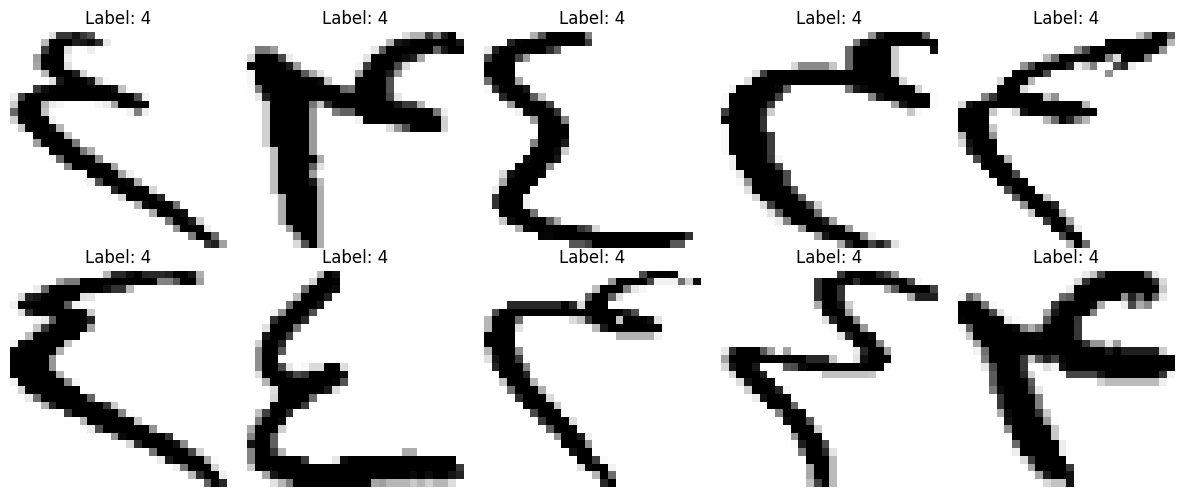

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_raw[i], cmap="gray")
    plt.title(f"Label: {y_raw[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:

assert len(X_raw) > 0, "هیچ تصویری خوانده نشده است؛ مرحله ۲ و ۳ را بررسی کن."


X = X_raw / 255.0


X = X.reshape(X.shape[0], -1)


y = np.eye(10)[y_raw]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_raw
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


X_train shape: (1358, 784)
y_train shape: (1358, 10)
X_test shape : (340, 784)
y_test shape : (340, 10)


In [ ]:
class MultiClassMLP:
    def __init__(self, input_dim=784, hidden_dim=64, output_dim=10, lr=0.05):
        self.lr = lr

        # مقداردهی اولیه He برای ReLU
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

        self.losses = []

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def softmax(self, Z):

        # برای پایداری عددی
        Z = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-12
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        return -np.mean(
            np.sum(y_true * np.log(y_pred), axis=1)
        )

    def forward(self, X):
        # لایه ورودی → مخفی
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.relu(self.Z1)

        # لایه مخفی → خروجی
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self.softmax(self.Z2)

        return self.A2

    def backward(self, X, y_true, y_pred):
        n_samples = X.shape[0]

        # گرادیان لایه خروجی
        dZ2 = (y_pred - y_true) / n_samples
        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # گرادیان لایه مخفی
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # به‌روزرسانی وزن‌ها و بایاس‌ها
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=800, verbose=True):
        self.losses = []

        for epoch in range(epochs):
            # Forward
            y_pred = self.forward(X)

            # Loss
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)

            # Backward
            self.backward(X, y, y_pred)

            # نمایش هر 100 epoch
            if verbose and ((epoch + 1) % 100 == 0 or epoch == 0):
                print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss:.4f}")

    def predict(self, X):
        probabilities = self.forward(X)
        return np.argmax(probabilities, axis=1)


In [1]:

model = MultiClassMLP(
    input_dim=784,
    hidden_dim=64,
    output_dim=10,
    lr=0.05
)

model.fit(X_train, y_train, epochs=800, verbose=True)

plt.figure(figsize=(8, 4))
plt.plot(model.losses, color="darkblue", lw=2)
plt.title("Hoda Dataset - Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()


NameError: name 'MultiClassMLP' is not defined

In [ ]:

y_pred = model.predict(X_test)

y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 86.47%


              precision    recall  f1-score   support

           0       0.90      0.80      0.85        35
           1       0.89      0.91      0.90        34
           2       0.86      0.91      0.88        33
           3       0.86      0.94      0.90        34
           4       0.76      0.80      0.78        35
           5       0.91      0.91      0.91        34
           6       0.77      0.69      0.73        35
           7       0.84      0.91      0.87        34
           8       1.00      0.88      0.94        34
           9       0.88      0.91      0.89        32

    accuracy                           0.86       340
   macro avg       0.87      0.87      0.87       340
weighted avg       0.87      0.86      0.86       340



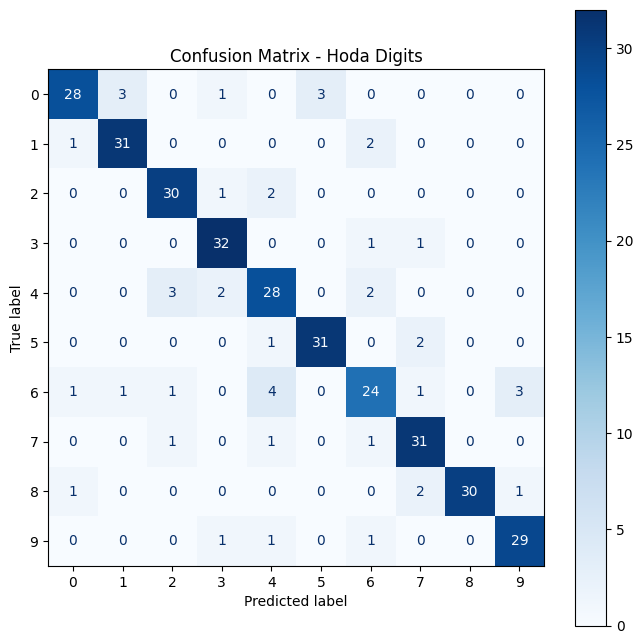

In [ ]:

print(classification_report(y_true, y_pred))


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Hoda Digits")
plt.show()
